In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

from matplotlib.ticker import FormatStrFormatter
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
# # Add photo-z's

# cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/main/main-lrg-daily-thru20210615.fits'))
# print(len(cat))

# from desitarget.targets import encode_targetid

# def decode_sweep_name(sweepname):
#     sweepname = os.path.basename(sweepname)

#     ramin, ramax = float(sweepname[6:9]), float(sweepname[14:17])
#     decmin, decmax = float(sweepname[10:13]), float(sweepname[18:21])

#     if sweepname[9] == 'm':
#         decmin *= -1
#     if sweepname[17] == 'm':
#         decmax *= -1

#     return [ramin, ramax, decmin, decmax]

# def is_in_box(objs, radecbox, ra_col='RA', dec_col='DEC'):

#     ramin, ramax, decmin, decmax = radecbox

#     # ADM check for some common mistakes.
#     if decmin < -90. or decmax > 90. or decmax <= decmin or ramax <= ramin:
#         msg = "Strange input: [ramin, ramax, decmin, decmax] = {}".format(radecbox)
#         raise ValueError(msg)

#     ii = ((objs[ra_col] >= ramin) & (objs[ra_col] < ramax)
#           & (objs[dec_col] >= decmin) & (objs[dec_col] < decmax))

#     return ii


# # sweep columns to add
# ls_columns = ['MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2', 'NOBS_G', 'NOBS_R', 'NOBS_Z']

# print(len(cat))
# print(len(np.unique(cat['TARGETID'])))

# # Ignore any possible north/south overlap

# sweep_fn_list = []
# for field in ['north', 'south']:
#     sweep_dir = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/{}/sweep/9.0'.format(field)
#     sweep_fn_list += sorted(glob.glob(os.path.join(sweep_dir, '*.fits')))
# sweep_fn_list = np.array(sweep_fn_list)

# sweep_radec_list = [decode_sweep_name(sweep_fn) for sweep_fn in sweep_fn_list]
# mask = np.array([np.any(is_in_box(cat, sweep_radec, ra_col='TARGET_RA', dec_col='TARGET_DEC')) for sweep_radec in sweep_radec_list])
# print(np.sum(mask))
# sweep_fn_list = sweep_fn_list[mask]

# ls_stack = []
# for index, sweep_fn in enumerate(sweep_fn_list):
#     print(index, len(sweep_fn_list))
#     ls = Table(fitsio.read(sweep_fn, columns=['OBJID', 'BRICKID', 'RELEASE']))
#     targetid = encode_targetid(ls['OBJID'], ls['BRICKID'], ls['RELEASE'])
#     idx = np.where(np.in1d(targetid, cat['TARGETID']))[0]
#     if len(idx)==0:
#         continue
#     targetid = targetid[idx]
#     ls = Table(fitsio.read(sweep_fn, rows=idx, columns=ls_columns))
#     ls['TARGETID'] = targetid
#     if '/south/sweep/' in sweep_fn:
#         ls['field'] = 'south'
#     else:
#         ls['field'] = 'north'
#     pz_fn = sweep_fn.replace('sweep/9.0/', 'sweep/9.0-photo-z/').replace('.fits', '-pz.fits')
#     pz = Table(fitsio.read(pz_fn, rows=idx))
#     pz.remove_columns(['OBJID', 'BRICKID', 'RELEASE'])
#     ls = hstack([ls, pz])
#     ls_stack.append(ls)
# ls = vstack(ls_stack)
# print(len(cat), len(ls))

# cat = join(cat, ls, keys='TARGETID')
# cat.write('/global/cfs/cdirs/desi/users/rongpu/data/main/main-lrg-daily-thru20210615-add_pz.fits')

In [4]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/main/main-lrg-daily-thru20210615-add_pz.fits'))
print(len(cat))

291793


86880 204913


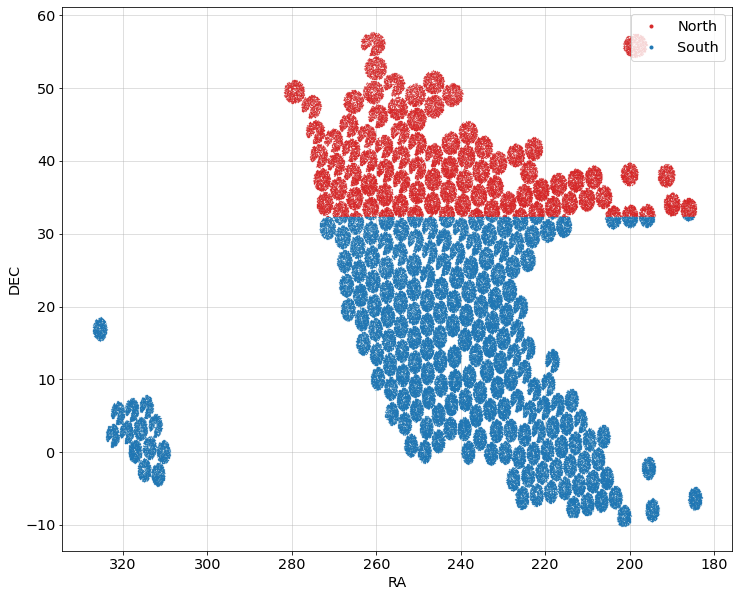

In [5]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'
print(np.sum(mask_north), np.sum(mask_south))

plt.figure(figsize=(12, 10))
plt.plot(cat['TARGET_RA'][mask_north], cat['TARGET_DEC'][mask_north], 'C3.', ms=.3, label='North')
plt.plot(cat['TARGET_RA'][mask_south], cat['TARGET_DEC'][mask_south], 'C0.', ms=.3, label='South')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=20)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [6]:
# Remove FIBERSTATUS!=0 fibers
mask = cat['FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
min_depth = 800.
mask = cat['COADD_EFFTIME_GFA']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# # Remove not-done fibers
# mask = cat['ZDONE']==1
# cat = cat[mask]
# print('ZDONE   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))

FIBERSTATUS    3475 288318 0.011909127360834564
No data    0 288318 0.0
Min depth    4533 283785 0.015722223378353068


In [7]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']) - 0.113 * cat['EBV']
    cat['rfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_R']) - 2.165 * cat['EBV']
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

In [8]:
mask_quality0 = cat['ZWARN']==0
mask_quality0 &= cat['DELTACHI2']>15
mask_quality0 &= cat['Z']<1.4
print(np.sum(~mask_quality0)/len(mask_quality0))

# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<10)
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.4
mask_quality &= (~mask_remove)
print(np.sum(~mask_quality)/len(mask_quality))

# Custom cut with DELTACHI2>15
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<15)
mask_quality1 = cat['ZWARN']==0
mask_quality1 &= cat['Z']<1.4
mask_quality1 &= (~mask_remove)
print(np.sum(~mask_quality1)/len(mask_quality1))

0.025473509875433866
0.023366280811177476
0.02730588297478725


In [9]:
cat = cat[mask_quality]
print(len(cat))

277154


In [10]:
# WISE and MEDIUM masks
maskbits = [8, 9, 11]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print('MASKBITS', np.sum(mask_clean), np.sum(~mask_clean), np.sum(mask_clean)/len(mask_clean))
cat = cat[mask_clean]

MASKBITS 255973 21181 0.9235767840262092


In [11]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'
print(np.sum(mask_north), np.sum(mask_south))

77416 178557


In [12]:
# numbers from another notebook
area_tot = 10109.0
n_mask_tot = 6159414
density_tot = n_mask_tot/area_tot
print(density_tot)

area_south = np.sum(mask_south)/n_mask_tot * area_tot
print(area_south)

area_north = np.sum(mask_north)/n_mask_tot * area_tot
print(area_north)

area = area_south + area_north
print(area)

609.3000296765259
293.0526691337845
127.05727265613254
420.109941789917


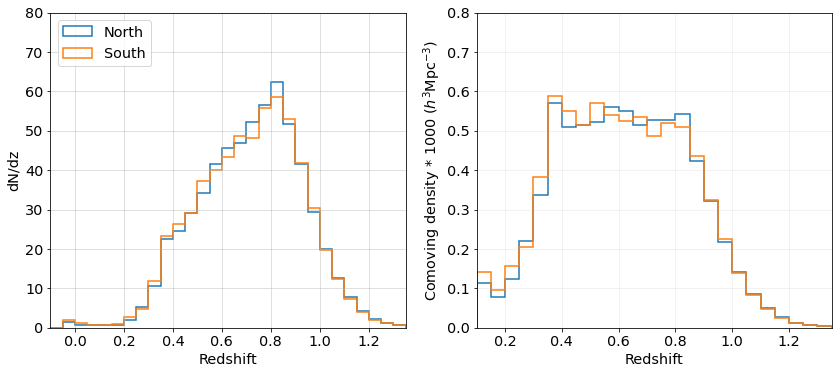

In [13]:
bins = np.arange(-0.1, 1.45, 0.05)
bin_centers = (bins[1:]+bins[:-1])/2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].hist(cat['Z'][mask_north], weights=np.ones(int(np.sum(mask_north)))/area_north,
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
axes[0].hist(cat['Z'][mask_south], weights=np.ones(int(np.sum(mask_south)))/area_south,
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# axes[0].hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.35)
axes[0].set_ylim(0, 80)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_north], area=area_north, zmin=0.1, zmax=bins.max(), dz=0.05, axis=[0.1, 1.35, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=False)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_south], area=area_south, zmin=0.1, zmax=bins.max(), dz=0.05, axis=[0.1, 1.35, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=False)
# plt.legend(loc='lower left')
plt.show()

---------
# r-W1 bins

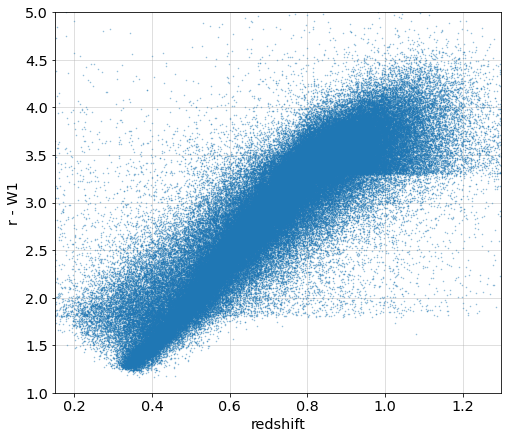

In [14]:
plt.figure(figsize=(8, 7))
plt.plot(cat['Z'][mask_south], (cat['rmag']-cat['w1mag'])[mask_south], '.', ms=1, alpha=0.5)
plt.xlabel('redshift')
plt.ylabel('r - W1')
plt.axis([0.15, 1.3, 1, 5])
plt.grid(alpha=0.5)
plt.show()

In [15]:
rw1_cuts_south = [2.24, 2.82, 3.3, 3.54]
rw1_cuts_north = [2.32, 2.92, 3.4, 3.65]

print('South:')
for index in range(-1, len(rw1_cuts_south)):
    if index==-1:
        rw1_min, rw1_max = -np.inf, rw1_cuts_south[0]
    elif index==len(rw1_cuts_south)-1:
        rw1_min, rw1_max = rw1_cuts_south[index], np.inf
    else:
        rw1_min, rw1_max = rw1_cuts_south[index], rw1_cuts_south[index+1]
    mask = mask_south & (cat['rmag']-cat['w1mag']>rw1_min) & (cat['rmag']-cat['w1mag']<rw1_max)
    print('bin {} fraction: {:.4f}'.format(index+2, np.sum(mask)/np.sum(mask_south)))

print()
print('North:')
for index in range(-1, len(rw1_cuts_north)):
    if index==-1:
        rw1_min, rw1_max = -np.inf, rw1_cuts_north[0]
    elif index==len(rw1_cuts_north)-1:
        rw1_min, rw1_max = rw1_cuts_north[index], np.inf
    else:
        rw1_min, rw1_max = rw1_cuts_north[index], rw1_cuts_north[index+1]
    mask = mask_north & (cat['rmag']-cat['w1mag']>rw1_min) & (cat['rmag']-cat['w1mag']<rw1_max)
    print('bin {} fraction: {:.4f}'.format(index+2, np.sum(mask)/np.sum(mask_north)))

South:
bin 1 fraction: 0.2141
bin 2 fraction: 0.2002
bin 3 fraction: 0.1977
bin 4 fraction: 0.1926
bin 5 fraction: 0.1954

North:
bin 1 fraction: 0.2088
bin 2 fraction: 0.2056
bin 3 fraction: 0.2003
bin 4 fraction: 0.1979
bin 5 fraction: 0.1874


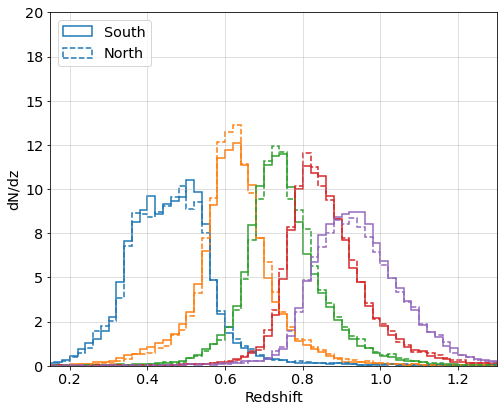

In [16]:
bins = np.arange(-0.1, 1.45, 0.02)
bin_centers = (bins[1:]+bins[:-1])/2

fig, ax = plt.subplots(figsize=(8, 6.5))

for index in range(-1, len(rw1_cuts_south)):
    if index==-1:
        rw1_min, rw1_max = -np.inf, rw1_cuts_south[0]
    elif index==len(rw1_cuts_south)-1:
        rw1_min, rw1_max = rw1_cuts_south[index], np.inf
    else:
        rw1_min, rw1_max = rw1_cuts_south[index], rw1_cuts_south[index+1]
    if index==-1:
        label = 'South'
    else:
        label = None
    mask = mask_south & (cat['rmag']-cat['w1mag']>rw1_min) & (cat['rmag']-cat['w1mag']<rw1_max)
    ax.hist(cat['Z'][mask], weights=np.ones(int(np.sum(mask)))/area_south,
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(index+1))
for index in range(-1, len(rw1_cuts_north)):
    if index==-1:
        rw1_min, rw1_max = -np.inf, rw1_cuts_north[0]
    elif index==len(rw1_cuts_north)-1:
        rw1_min, rw1_max = rw1_cuts_north[index], np.inf
    else:
        rw1_min, rw1_max = rw1_cuts_north[index], rw1_cuts_north[index+1]
    if index==-1:
        label = 'North'
    else:
        label = None
    mask = mask_north & (cat['rmag']-cat['w1mag']>rw1_min) & (cat['rmag']-cat['w1mag']<rw1_max)
    ax.hist(cat['Z'][mask], weights=np.ones(int(np.sum(mask)))/area_north,
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(index+1), ls='--')

ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('dN/dz')
ax.set_xlim(0.15, 1.3)
ax.set_ylim(0, 20)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.grid(alpha=0.5)
# ax.set_ylim(top=30)
# plt.legend(loc='lower left')
plt.show()

In [17]:
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)

bins = np.round(np.arange(0., 1.5, 0.02), 2)

t = Table()
t['zmin'] = bins[:-1]
t['zmax'] = bins[1:]

for index in range(-1, len(rw1_cuts_north)):
    if index==-1:
        rw1_min, rw1_max = -np.inf, rw1_cuts_north[0]
    elif index==len(rw1_cuts_north)-1:
        rw1_min, rw1_max = rw1_cuts_north[index], np.inf
    else:
        rw1_min, rw1_max = rw1_cuts_north[index], rw1_cuts_north[index+1]
    mask = mask_north & (cat['rmag']-cat['w1mag']>rw1_min) & (cat['rmag']-cat['w1mag']<rw1_max)
    mask &= (~mask_star)
    counts = np.histogram(cat['Z'][mask], bins=bins)[0]
    surf_density = counts/area_north
    t['bin_{}_north'.format(index+2)] = surf_density
    t['bin_{}_north'.format(index+2)].format = '%.1f'

for index in range(-1, len(rw1_cuts_south)):
    if index==-1:
        rw1_min, rw1_max = -np.inf, rw1_cuts_south[0]
    elif index==len(rw1_cuts_south)-1:
        rw1_min, rw1_max = rw1_cuts_south[index], np.inf
    else:
        rw1_min, rw1_max = rw1_cuts_south[index], rw1_cuts_south[index+1]
    mask = mask_south & (cat['rmag']-cat['w1mag']>rw1_min) & (cat['rmag']-cat['w1mag']<rw1_max)
    mask &= (~mask_star)
    counts = np.histogram(cat['Z'][mask], bins=bins)[0]
    surf_density = counts/area_south
    t['bin_{}_south'.format(index+2)] = surf_density
    t['bin_{}_south'.format(index+2)].format = '%.1f'
    
t.write('data/main_lrg_rw1_dndz_v0.1.txt', format='ascii.commented_header', overwrite=True)

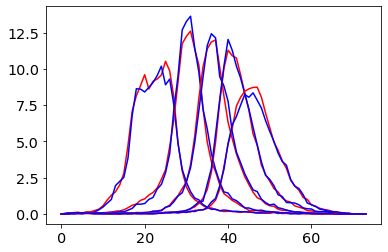

In [18]:
for index in range(-1, len(rw1_cuts_south)):
    plt.plot(t['bin_{}_south'.format(index+2)], color='r')
    plt.plot(t['bin_{}_north'.format(index+2)], color='b')
plt.axis
plt.show()

---------
# Photo-z bins

In [19]:
pz_cuts_south = [0.540, 0.683, 0.810, 0.890]
pz_cuts_north = [0.552, 0.691, 0.812, 0.885]

print('South:')
for index in range(-1, len(pz_cuts_south)):
    if index==-1:
        pz_min, pz_max = -np.inf, pz_cuts_south[0]
    elif index==len(pz_cuts_south)-1:
        pz_min, pz_max = pz_cuts_south[index], np.inf
    else:
        pz_min, pz_max = pz_cuts_south[index], pz_cuts_south[index+1]
    mask = mask_south & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    print('bin {} fraction: {:.4f}'.format(index+2, np.sum(mask)/np.sum(mask_south)))

print()
print('North:')
for index in range(-1, len(pz_cuts_north)):
    if index==-1:
        pz_min, pz_max = -np.inf, pz_cuts_north[0]
    elif index==len(pz_cuts_north)-1:
        pz_min, pz_max = pz_cuts_north[index], np.inf
    else:
        pz_min, pz_max = pz_cuts_north[index], pz_cuts_north[index+1]
    mask = mask_north & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    print('bin {} fraction: {:.4f}'.format(index+2, np.sum(mask)/np.sum(mask_north)))

South:
bin 1 fraction: 0.2045
bin 2 fraction: 0.1976
bin 3 fraction: 0.2005
bin 4 fraction: 0.1955
bin 5 fraction: 0.2020

North:
bin 1 fraction: 0.2017
bin 2 fraction: 0.2018
bin 3 fraction: 0.1973
bin 4 fraction: 0.1959
bin 5 fraction: 0.2034


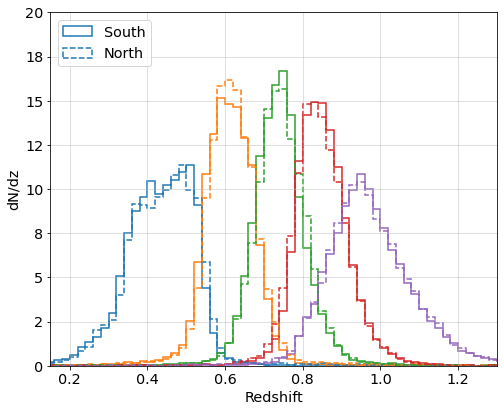

In [20]:
bins = np.arange(-0.1, 1.45, 0.02)
bin_centers = (bins[1:]+bins[:-1])/2

fig, ax = plt.subplots(figsize=(8, 6.5))

for index in range(-1, len(pz_cuts_south)):
    if index==-1:
        pz_min, pz_max = -np.inf, pz_cuts_south[0]
    elif index==len(pz_cuts_south)-1:
        pz_min, pz_max = pz_cuts_south[index], np.inf
    else:
        pz_min, pz_max = pz_cuts_south[index], pz_cuts_south[index+1]
    if index==-1:
        label = 'South'
    else:
        label = None
    mask = mask_south & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    ax.hist(cat['Z'][mask], weights=np.ones(int(np.sum(mask)))/area_south,
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(index+1))
for index in range(-1, len(pz_cuts_north)):
    if index==-1:
        pz_min, pz_max = -np.inf, pz_cuts_north[0]
    elif index==len(pz_cuts_north)-1:
        pz_min, pz_max = pz_cuts_north[index], np.inf
    else:
        pz_min, pz_max = pz_cuts_north[index], pz_cuts_north[index+1]
    if index==-1:
        label = 'North'
    else:
        label = None
    mask = mask_north & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    ax.hist(cat['Z'][mask], weights=np.ones(int(np.sum(mask)))/area_north,
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(index+1), ls='--')

ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('dN/dz')
ax.set_xlim(0.15, 1.3)
ax.set_ylim(0, 20)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.grid(alpha=0.5)
# ax.set_ylim(top=30)
# plt.legend(loc='lower left')
plt.show()

In [21]:
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)

bins = np.round(np.arange(0., 1.5, 0.02), 2)

t = Table()
t['zmin'] = bins[:-1]
t['zmax'] = bins[1:]

for index in range(-1, len(pz_cuts_north)):
    if index==-1:
        pz_min, pz_max = -np.inf, pz_cuts_north[0]
    elif index==len(pz_cuts_north)-1:
        pz_min, pz_max = pz_cuts_north[index], np.inf
    else:
        pz_min, pz_max = pz_cuts_north[index], pz_cuts_north[index+1]
    mask = mask_north & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    mask &= (~mask_star)
    counts = np.histogram(cat['Z'][mask], bins=bins)[0]
    surf_density = counts/area_north
    t['bin_{}_north'.format(index+2)] = surf_density
    t['bin_{}_north'.format(index+2)].format = '%.1f'

for index in range(-1, len(pz_cuts_south)):
    if index==-1:
        pz_min, pz_max = -np.inf, pz_cuts_south[0]
    elif index==len(pz_cuts_south)-1:
        pz_min, pz_max = pz_cuts_south[index], np.inf
    else:
        pz_min, pz_max = pz_cuts_south[index], pz_cuts_south[index+1]
    mask = mask_south & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    mask &= (~mask_star)
    counts = np.histogram(cat['Z'][mask], bins=bins)[0]
    surf_density = counts/area_south
    t['bin_{}_south'.format(index+2)] = surf_density
    t['bin_{}_south'.format(index+2)].format = '%.1f'
    
t.write('data/main_lrg_pz_dndz_v0.1.txt', format='ascii.commented_header', overwrite=True)

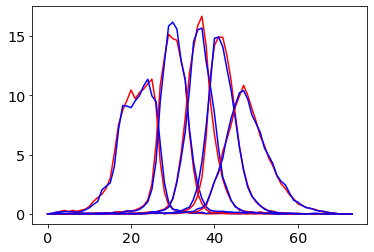

In [22]:
for index in range(-1, len(rw1_cuts_south)):
    plt.plot(t['bin_{}_south'.format(index+2)], color='r')
    plt.plot(t['bin_{}_north'.format(index+2)], color='b')
plt.show()